## 개요
따릉이 수요를 예측해본다.               
지역구는 은평구로 한정하며 군집화를 통하여 12개의 군집으로 나누었고 그 중에 3개를 뽑아서 진행한다

In [23]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

================================================================== 


01. 파일 로드

In [24]:
df2024 = pd.read_csv('../../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../../Data/Zero/2025_data.csv')

df = pd.concat([df2024,df2025],axis=0)
kr = holidays.KR()

In [25]:
df

,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01,0,출발시간,ST-481,ST-1692,1.0,3000,10340.0,-2.7,92,28.49784,0.0,0.0
1,2024-01-01,0,출발시간,ST-464,ST-456,1.0,2040,1900.0,-2.7,92,28.49784,0.0,0.0
2,2024-01-01,0,출발시간,ST-1486,ST-462,1.0,1140,1610.0,-2.7,92,28.49784,0.0,0.0
3,2024-01-01,0,출발시간,ST-2783,ST-462,1.0,4740,5725.0,-2.7,92,28.49784,0.0,0.0
4,2024-01-01,0,출발시간,ST-454,ST-1331,1.0,6900,11170.0,-2.7,92,28.49784,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
739708,2025-12-31,23,출발시간,ST-1034,ST-2207,1.0,120,448.0,-8.8,51,27.43588,0.0,0.0
739709,2025-12-31,23,출발시간,ST-2264,ST-479,1.0,180,334.0,-8.8,51,27.43588,0.0,0.0
739710,2025-12-31,23,출발시간,ST-479,ST-1025,1.0,420,1262.0,-8.8,51,27.43588,0.0,0.0
739711,2025-12-31,23,출발시간,ST-2470,ST-2425,1.0,1140,2659.0,-8.8,51,27.43588,0.0,0.0


==================================================================   


02. 지정된 스테이션으로 통합
- 3개 뽑은 스테이션을 정의함                
- 기준 날짜를 datetime으로 전환
- 전체 이용 시간과 전체 이용 거리가 최소한 5이상인 것들만 추출함
- 시작 대여소가 뽑은 스테이션에 해당하는 데이터만 추출함
- 시작 대여소, datetime, year를 기준으로 그룹화함. 전체 건수의 합, 온도, 습도, 불쾌지수, 강수량, 적설량의 평균으로 집어 넣음

In [26]:
# 1. 시작 대여소 기준으로만 필터링 (순수 대여량 예측 목적)
target_station = ['ST-464','ST-481','ST-479']
# target_station = ['ST-1035', 'ST-454', 'ST-471']
df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['year'] = df['기준_날짜'].dt.year
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)
df = df[(df['전체_이용_분'] >= 5) & (df['전체_이용_거리'] >= 5)]
df['datetime'] = pd.to_datetime(df['기준_날짜']) + pd.to_timedelta(df['시간대'], unit='h')
df = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_hourly = df.groupby(['시작_대여소_ID', 'datetime','year']).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '불쾌지수': 'mean',
    '강수량': 'mean',
    '적설량': 'mean'
}).reset_index()


==================================================================        


03. 전처리 - 1
- datetime을 기준으로 hour, month, weekday, is_weekend, is_holiday 값 추출
- 1시간, 2시간, 3시간, 24시간 전 데이터를 가져옴
- 1시간 전을 기준으로 3시간의 평균 계산
- 시간을 sin과 cos으로 저장
- 달을 sin과 cos으로 저장

In [27]:
# 1. 시간대와 요일 정보 다시 추출
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['month'] = df_hourly['datetime'].dt.month

df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = np.where(df_hourly['weekday'] < 5, 0, 1)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr)

df_hourly['rush_hour'] = (
    ((df_hourly['hour'] >= 7) & (df_hourly['hour'] <= 9)) |
    ((df_hourly['hour'] >= 17) & (df_hourly['hour'] <= 19))
).astype(int)

# 2. 대여소 ID를 숫자로 변환 (HGB가 대여소별 특징을 알게 함)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# df_hourly['station_idx'] = le.fit_transform(df_hourly['시작_대여소_ID'])
df_hourly = df_hourly.sort_values(['시작_대여소_ID', 'datetime'])



df_hourly['lag_1h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(1)
df_hourly['lag_2h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(2)
df_hourly['lag_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(3)
df_hourly['lag_12h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(12)

df_hourly['lag_24h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].shift(24)

df_hourly['rolling_3h'] = df_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.shift(1).rolling(3).mean())

df_hourly = df_hourly.dropna()

df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['month_sin'] = np.sin(2 * np.pi * df_hourly['month'] / 12)
df_hourly['month_cos'] = np.cos(2 * np.pi * df_hourly['month'] / 12)


In [28]:
df_hourly

,시작_대여소_ID,datetime,year,전체_건수,온도,습도,불쾌지수,강수량,적설량,hour,...,lag_1h,lag_2h,lag_3h,lag_12h,lag_24h,rolling_3h,hour_sin,hour_cos,month_sin,month_cos
24,ST-464,2024-01-03 15:00:00,2024,2.0,3.0,76.0,40.11920,0.0,0.0,15,...,2.0,2.0,2.0,4.0,2.0,2.000000,-0.707107,-7.071068e-01,5.000000e-01,0.866025
25,ST-464,2024-01-03 16:00:00,2024,6.0,2.8,75.0,39.92200,0.0,0.0,16,...,2.0,2.0,2.0,4.0,2.0,2.000000,-0.866025,-5.000000e-01,5.000000e-01,0.866025
26,ST-464,2024-01-03 17:00:00,2024,2.0,1.4,80.0,37.10280,0.0,0.0,17,...,6.0,2.0,2.0,6.0,2.0,3.333333,-0.965926,-2.588190e-01,5.000000e-01,0.866025
27,ST-464,2024-01-03 19:00:00,2024,4.0,-1.0,85.0,32.49350,0.0,0.0,19,...,2.0,6.0,2.0,6.0,2.0,3.333333,-0.965926,2.588190e-01,5.000000e-01,0.866025
28,ST-464,2024-01-03 20:00:00,2024,6.0,-1.9,85.0,31.00715,0.0,0.0,20,...,4.0,2.0,6.0,4.0,4.0,4.000000,-0.866025,5.000000e-01,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38138,ST-481,2025-12-31 17:00:00,2025,4.0,-5.8,38.0,33.98604,0.0,0.0,17,...,2.0,2.0,4.0,2.0,4.0,2.666667,-0.965926,-2.588190e-01,-2.449294e-16,1.000000
38139,ST-481,2025-12-31 18:00:00,2025,8.0,-6.6,42.0,32.20372,0.0,0.0,18,...,4.0,2.0,2.0,2.0,4.0,2.666667,-1.000000,-1.836970e-16,-2.449294e-16,1.000000
38140,ST-481,2025-12-31 19:00:00,2025,3.0,-7.2,43.0,31.25396,0.0,0.0,19,...,8.0,4.0,2.0,2.0,4.0,4.666667,-0.965926,2.588190e-01,-2.449294e-16,1.000000
38141,ST-481,2025-12-31 20:00:00,2025,3.0,-7.9,45.0,29.94655,0.0,0.0,20,...,3.0,8.0,4.0,2.0,2.0,5.000000,-0.866025,5.000000e-01,-2.449294e-16,1.000000


==================================================================        


03. 전처리 - 2
- 데이터에 없는 비어 있는 시간대를 만든다.
- 모든 대여소와 모든 시간을 카테시안 곱으로 결합해서 전체 조합을 만듬.
- 전체 건수가 널이면 0으로 채움
- 기상 변수들을 앞의 값으로 채워줌
- 타켓 스테이션들을 one hot encoding으로 넣어줌(근데 안 씀)
- 요일을 one hot encoding으로 넣어줌(근데 안 씀)

In [29]:
# all_stations = df_hourly['시작_대여소_ID'].unique()
all_times = pd.date_range(start=df_hourly['datetime'].min(), 
                          end=df_hourly['datetime'].max(), 
                          freq='h')

multi_idx = pd.MultiIndex.from_product([target_station, all_times], 
                                       names=['시작_대여소_ID', 'datetime'])
df_full = pd.DataFrame(index=multi_idx).reset_index()

df_hourly = pd.merge(df_full, df_hourly, on=['시작_대여소_ID', 'datetime'], how='left')

df_hourly['전체_건수'] = df_hourly['전체_건수'].fillna(0) # 대여 없는 시간은 0건
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['month'] = df_hourly['datetime'].dt.month
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly[['온도', '습도', '불쾌지수', '강수량', '적설량']] = \
    df_hourly.groupby('시작_대여소_ID')[['온도', '습도', '불쾌지수', '강수량', '적설량']].ffill()


df_hourly = pd.get_dummies(df_hourly, columns=['시작_대여소_ID'], prefix='st')
df_hourly = pd.get_dummies(df_hourly, columns=['weekday'])
# 2. 새로운 피처 리스트 생성 (기 station_idx 제외하고 새로 생긴 st_... 컬럼들 추가)
station_cols = [col for col in df_hourly.columns if col.startswith('st_')]
weekday_cols = [col for col in df_hourly.columns if col.startswith('week_')]
target = '전체_건수'
features = [
    # 'hour',
      # 'weekday', 
      # 'datetime',
    # 'is_weekend',
    #  'is_holiday',
    '온도', '습도',
      # '불쾌지수',
        '강수량', '적설량',
    # 'lag_1h', 
    # 'lag_2h',
    #   'rolling_3h',
    # 'lag_12h',
      # 'lag_24h',
    'hour_sin',
    'month_sin',
      'hour_cos',
      'month_cos',
      # 'rush_hour'
'st_ST-464', 'st_ST-481', 'st_ST-479',
       'weekday_0.0', 'weekday_1.0', 'weekday_2.0', 'weekday_3.0',
       'weekday_4.0', 'weekday_5.0', 'weekday_6.0'
]

In [30]:
df_hourly.columns

Index(['datetime', 'year', '전체_건수', '온도', '습도', '불쾌지수', '강수량', '적설량', 'hour',
       'month', 'is_weekend', 'is_holiday', 'rush_hour', 'lag_1h', 'lag_2h',
       'lag_3h', 'lag_12h', 'lag_24h', 'rolling_3h', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'st_ST-464', 'st_ST-479', 'st_ST-481',
       'weekday_0.0', 'weekday_1.0', 'weekday_2.0', 'weekday_3.0',
       'weekday_4.0', 'weekday_5.0', 'weekday_6.0'],
      dtype='str')

==================================================================         


04. 값
- 2024년은 train, 2025년은 test로 지정
- 주차별(7일 x 24시간) 패턴 유사도를 먼저 확인함
- 필요하면 유사한 주차를 제거할 수 있게 함
- HistGradientBoostingRegressor 모델 사용해서 학습


In [ ]:
SIMILAR_WEEK_FILTER = False
SIMILARITY_THRESHOLD = 0.998
COMPARE_WITHIN_STATION = True
SIMILARITY_PREVIEW_TOP_N = 20

def build_weekly_similarity_pairs(df, within_station=True):
    work = df.copy()
    work['week_start'] = work['datetime'].dt.to_period('W-MON').apply(lambda r: r.start_time)
    work['dow'] = work['datetime'].dt.dayofweek
    work['slot_in_week'] = work['dow'] * 24 + work['hour']

    group_keys = []
    if within_station:
        group_keys.append('st_group')
        station_dummy_cols = [col for col in work.columns if col.startswith('st_')]
        work['st_group'] = (
            work[station_dummy_cols]
            .idxmax(axis=1)
            .str.replace('st_', '', regex=False)
        )
    else:
        work['st_group'] = 'all_station'

    pair_records = []

    for group_values, group_df in work.groupby(group_keys, dropna=False):
        weekly_profile = (
            group_df.groupby(['week_start', 'slot_in_week'])['전체_건수']
            .sum()
            .unstack(fill_value=0)
            .reindex(columns=range(168), fill_value=0)
            .sort_index()
        )

        week_counts = group_df.groupby('week_start')['slot_in_week'].nunique()
        full_weeks = week_counts[week_counts == 168].index
        weekly_profile = weekly_profile.loc[weekly_profile.index.isin(full_weeks)]

        if len(weekly_profile) < 2:
            continue

        norm = np.linalg.norm(weekly_profile.values, axis=1, keepdims=True)
        norm[norm == 0] = 1
        normalized = weekly_profile.values / norm
        group_info = group_values if isinstance(group_values, tuple) else (group_values,)
        group_name = ' | '.join(map(str, group_info))

        for i in range(len(weekly_profile.index)):
            for j in range(i + 1, len(weekly_profile.index)):
                similarity = float(normalized[i] @ normalized[j])
                pair_records.append(
                    {
                        '주차_1': weekly_profile.index[i].date(),
                        '주차_2': weekly_profile.index[j].date(),
                        'cosine_similarity': similarity,
                        '비교그룹': group_name,
                    }
                )

    pair_df = pd.DataFrame(pair_records)
    if pair_df.empty:
        return pair_df

    return pair_df.sort_values('cosine_similarity', ascending=False).reset_index(drop=True)

def drop_similar_train_weeks(df, threshold=0.998, within_station=True):
    similarity_pairs = build_weekly_similarity_pairs(df, within_station=within_station)

    if similarity_pairs.empty:
        return df.copy(), pd.DataFrame(), similarity_pairs

    removed_weeks = set()
    removed_records = []

    for _, row in similarity_pairs.iterrows():
        week_1 = pd.Timestamp(row['주차_1'])
        week_2 = pd.Timestamp(row['주차_2'])

        if row['cosine_similarity'] < threshold:
            break

        if week_1 in removed_weeks or week_2 in removed_weeks:
            continue

        removed_weeks.add(week_2)
        removed_records.append(
            {
                '제거_주차': week_2.date(),
                '유사_기준_주차': week_1.date(),
                'cosine_similarity': row['cosine_similarity'],
                '비교그룹': row['비교그룹'],
            }
        )

    filtered = df[~df['datetime'].dt.to_period('W-MON').apply(lambda r: r.start_time).isin(removed_weeks)].copy()
    removed_df = pd.DataFrame(removed_records)
    return filtered, removed_df, similarity_pairs

train = df_hourly[df_hourly['year'] == 2024].copy()
test  = df_hourly[df_hourly['year'] == 2025].copy()

train_before_filter_rows = len(train)
train_before_filter_weeks = train['datetime'].dt.to_period('W-MON').nunique()

similarity_pairs = build_weekly_similarity_pairs(
    train,
    within_station=COMPARE_WITHIN_STATION,
)

display(similarity_pairs.head(SIMILARITY_PREVIEW_TOP_N))

removed_train_weeks = pd.DataFrame(columns=['제거_주차', '유사_기준_주차', 'cosine_similarity', '비교그룹'])
if SIMILAR_WEEK_FILTER:
    train, removed_train_weeks, similarity_pairs = drop_similar_train_weeks(
        train,
        threshold=SIMILARITY_THRESHOLD,
        within_station=COMPARE_WITHIN_STATION,
    )

train_after_filter_rows = len(train)
train_after_filter_weeks = train['datetime'].dt.to_period('W-MON').nunique()

similar_week_summary = pd.DataFrame([
    {
        '구분': 'train_before_filter',
        '행수': train_before_filter_rows,
        '주차수': train_before_filter_weeks,
        '설명': '필터 적용 전',
    },
    {
        '구분': 'train_after_filter',
        '행수': train_after_filter_rows,
        '주차수': train_after_filter_weeks,
        '설명': '필터 적용 후',
    },
    {
        '구분': 'removed_weeks',
        '행수': len(removed_train_weeks) * 24 * 7,
        '주차수': len(removed_train_weeks),
        '설명': f'threshold={SIMILARITY_THRESHOLD}, station={COMPARE_WITHIN_STATION}',
    },
])

display(similar_week_summary)
display(removed_train_weeks.head(20))

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

x_input, x_valid, y_input, y_valid = train_test_split(
    X_train, y_train, random_state=42, test_size=0.2 ,shuffle=False
)

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

scores = cross_validate(
    hgb,
    X_train,
    np.log1p(y_train),
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

print('CV train score(log) mean:', np.mean(scores['train_score']))
print('CV valid score(log) mean:', np.mean(scores['test_score']))
print('=' * 50)

hgb.fit(x_input, np.log1p(y_input))
print('Input score(log):', hgb.score(x_input, np.log1p(y_input)))
print('Valid score(log):', hgb.score(x_valid, np.log1p(y_valid)))
print('=' * 50)

pred_input = np.expm1(hgb.predict(x_input))
pred_valid = np.expm1(hgb.predict(x_valid))
print('INPUT MAE :', mean_absolute_error(y_input, pred_input))
print('INPUT RMSE:', np.sqrt(mean_squared_error(y_input, pred_input)))
print('INPUT R2  :', r2_score(y_input, pred_input))
print('-' * 50)
print('VALID MAE :', mean_absolute_error(y_valid, pred_valid))
print('VALID RMSE:', np.sqrt(mean_squared_error(y_valid, pred_valid)))
print('VALID R2  :', r2_score(y_valid, pred_valid))
print('=' * 50)

hgb.fit(X_train, np.log1p(y_train))
pred_train = np.expm1(hgb.predict(X_train))
pred_test = np.expm1(hgb.predict(X_test))
print('TRAIN MAE :', mean_absolute_error(y_train, pred_train))
print('TRAIN RMSE:', np.sqrt(mean_squared_error(y_train, pred_train)))
print('TRAIN R2  :', r2_score(y_train, pred_train))
print('-' * 50)
print('TEST MAE :', mean_absolute_error(y_test, pred_test))
print('TEST RMSE:', np.sqrt(mean_squared_error(y_test, pred_test)))
print('TEST R2  :', r2_score(y_test, pred_test))


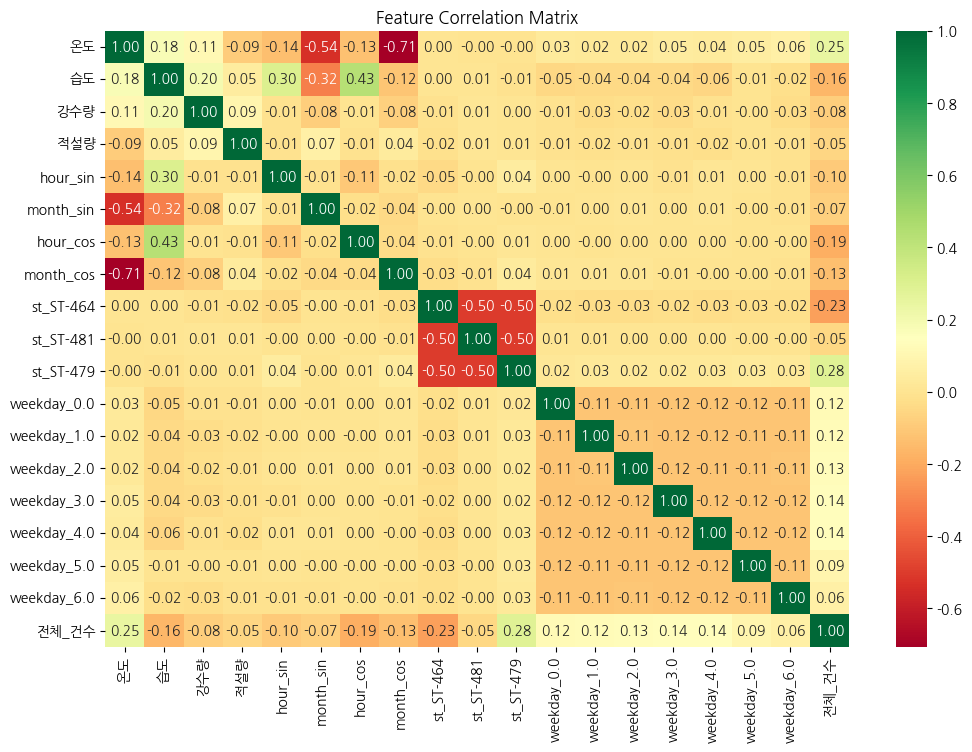

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 분석에 사용할 변수들만 추출
corr_df = df_hourly[features + [target]]

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

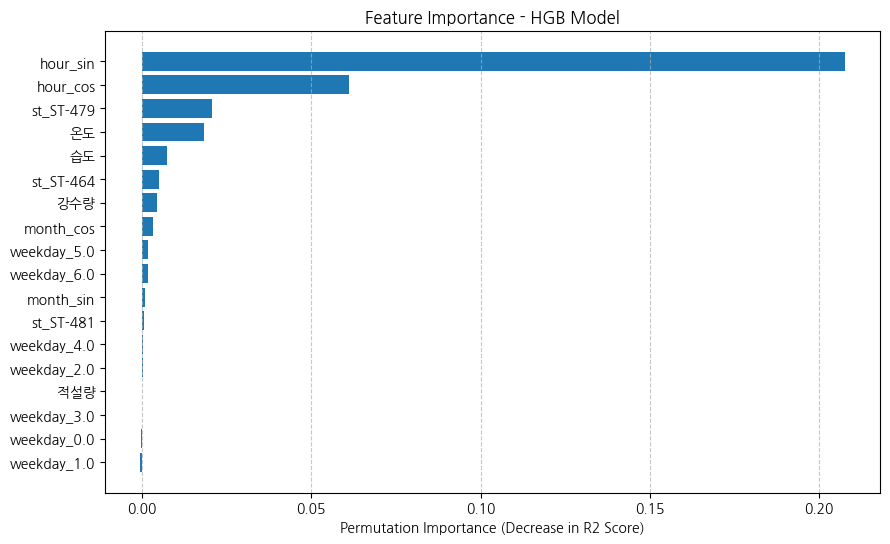

In [33]:
from sklearn.inspection import permutation_importance

# 테스트 데이터셋을 기준으로 측정합니다.
result = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42)

# 시각화를 위해 정렬
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Decrease in R2 Score)")
plt.title("Feature Importance - HGB Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()